# Veri Bilimi Final Ödevi - Ecrin Kaya

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
pd.set_option("display.max_columns", None)

In [25]:
!pip install -q gdown
import gdown
gdown.download('https://drive.google.com/uc?id=1rR1tG2lzCS20wKTkp0s9XZaK0iejjKL6', 'e_ticaret_veri_seti.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1rR1tG2lzCS20wKTkp0s9XZaK0iejjKL6
To: /content/e_ticaret_veri_seti.csv
100%|██████████| 202k/202k [00:00<00:00, 61.7MB/s]


'e_ticaret_veri_seti.csv'

In [26]:
df = pd.read_csv("e_ticaret_veri_seti.csv")
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,49.9,Kredi Kartı,Yeni,3.0,5.0,Hayır,0.220,443.68
1,SIP100837,MUS1347,2025-03-17 21:13:00,Gaziantep,Güneydoğu Anadolu,Spor,Dambıl Seti,2,1475.15,0.10,29.9,Banka Kartı,VIP,4.0,1.0,Hayır,0.361,2685.17
2,SIP100050,MUS1066,2025-06-03 12:42:00,Kayseri,İç Anadolu,Kitap,İş Analitiği Rehberi,1,289.02,0.05,29.9,Kredi Kartı,Mevcut,6.0,2.0,Hayır,0.348,304.47
3,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,49.9,Kapıda Ödeme,Yeni,3.0,5.0,Hayır,0.250,1023.80
4,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,39.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.280,2439.03


In [27]:
df.shape

(1428, 18)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1428 entries, 0 to 1427
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   siparis_id       1428 non-null   object 
 1   musteri_id       1428 non-null   object 
 2   siparis_tarihi   1428 non-null   object 
 3   sehir            1403 non-null   object 
 4   bolge            1428 non-null   object 
 5   kategori         1428 non-null   object 
 6   urun_adi         1428 non-null   object 
 7   adet             1428 non-null   int64  
 8   birim_fiyat      1428 non-null   float64
 9   indirim_orani    1412 non-null   float64
 10  kargo_ucreti     1428 non-null   float64
 11  odeme_turu       1393 non-null   object 
 12  musteri_tipi     1386 non-null   object 
 13  teslimat_gunu    1400 non-null   float64
 14  musteri_puani    1372 non-null   float64
 15  iade_durumu      1428 non-null   object 
 16  kar_marji_orani  1428 non-null   float64
 17  toplam_tutar  

#### Ön Hazırlık

In [29]:
df.isnull().sum()

,0
siparis_id,0
musteri_id,0
siparis_tarihi,0
sehir,25
bolge,0
kategori,0
urun_adi,0
adet,0
birim_fiyat,0
indirim_orani,16


In [30]:
sayisal_sutunlar = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
kategorik_sutunlar = df.select_dtypes(include=["object", "string"]).columns.tolist()

for sutun in sayisal_sutunlar:
    df[sutun] = df[sutun].fillna(df[sutun].median())

for sutun in kategorik_sutunlar:
    if df[sutun].isnull().sum() > 0:
        mod_degeri = df[sutun].mode()[0]
        df[sutun] = df[sutun].fillna(mod_degeri)

df.isnull().sum()

,0
siparis_id,0
musteri_id,0
siparis_tarihi,0
sehir,0
bolge,0
kategori,0
urun_adi,0
adet,0
birim_fiyat,0
indirim_orani,0


In [31]:
df["siparis_tarihi"] = pd.to_datetime(df["siparis_tarihi"])
df["siparis_yili"] = df["siparis_tarihi"].dt.year
df["siparis_ayi"] = df["siparis_tarihi"].dt.month
df["siparis_gunu"] = df["siparis_tarihi"].dt.day
df["haftanin_gunu"] = df["siparis_tarihi"].dt.day_name()
df.dtypes

,0
siparis_id,object
musteri_id,object
siparis_tarihi,datetime64[ns]
sehir,object
bolge,object
kategori,object
urun_adi,object
adet,int64
birim_fiyat,float64
indirim_orani,float64


In [32]:
tekrarlayan_kayit_sayisi = df.duplicated().sum()
tekrarlayan_kayit_sayisi

np.int64(28)

In [33]:
df = df.drop_duplicates()
df.shape

(1400, 22)

In [34]:
df["sehir"].unique()

array(['İstanbul', 'Gaziantep', 'Kayseri', 'Antalya', 'Konya', 'Ankara',
       'Bursa', 'Trabzon', 'Adana', 'Mersin', 'Kocaeli', 'İzmir',
       'Eskişehir', 'Samsun', 'istanbul', 'ankara', 'Istanbul',
       'gaziantep', 'Izmir'], dtype=object)

In [35]:
def metin_normalize_et(series):
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .str.replace("i̇", "i", regex=False)
        .str.replace("ı", "i", regex=False)
        .str.replace("ö", "o", regex=False)
        .str.replace("ü", "u", regex=False)
        .str.replace("ç", "c", regex=False)
        .str.replace("ş", "s", regex=False)
        .str.replace("ğ", "g", regex=False)
    )

df["sehir"] = metin_normalize_et(df["sehir"])

sehir_duzeltme_haritasi = {
    "istanbul": "İstanbul",
    "ankara": "Ankara",
    "izmir": "İzmir",
    "antalya": "Antalya",
    "konya": "Konya",
    "bursa": "Bursa",
    "adana": "Adana",
    "gaziantep": "Gaziantep",
    "mersin": "Mersin",
    "kayseri": "Kayseri",
    "eskisehir": "Eskişehir",
    "samsun": "Samsun",
    "trabzon": "Trabzon",
    "kocaeli": "Kocaeli",
}
df["sehir"] = df["sehir"].replace(sehir_duzeltme_haritasi)
df["sehir"].unique()

array(['İstanbul', 'Gaziantep', 'Kayseri', 'Antalya', 'Konya', 'Ankara',
       'Bursa', 'Trabzon', 'Adana', 'Mersin', 'Kocaeli', 'İzmir',
       'Eskişehir', 'Samsun'], dtype=object)

In [36]:
df["kategori"].unique()

array(['Kozmetik', 'Spor', 'Kitap', 'Elektronik', 'Ofis', 'ofis',
       'Ev ve Yaşam', 'Elektronik ', 'spor', 'kozmetık', 'ev ve yaşam',
       'kitap', 'Kozmetik ', 'elektronik', 'Ev&Yaşam'], dtype=object)

In [37]:
df["kategori"] = metin_normalize_et(df["kategori"])

kategori_duzeltme_haritasi = {
    "elektronik": "Elektronik",
    "kitap": "Kitap",
    "kozmetik": "Kozmetik",
    "kozmetık": "Kozmetik",
    "spor": "Spor",
    "ev ve yasam": "Ev ve Yaşam",
    "ev&yasam": "Ev ve Yaşam",
    "ofis": "Ofis",
}
df["kategori"] = df["kategori"].replace(kategori_duzeltme_haritasi)
df["kategori"].unique()

array(['Kozmetik', 'Spor', 'Kitap', 'Elektronik', 'Ofis', 'Ev ve Yaşam'],
      dtype=object)

In [38]:
df["odeme_turu"].unique()

array(['Kredi Kartı', 'Banka Kartı', 'Kapıda Ödeme', 'Dijital Cüzdan',
       'Havale/EFT', 'Kart', 'kredi kartı', 'dijital cüzdan', 'eft',
       'banka karti', 'Kapida Odeme', 'Havale'], dtype=object)

In [39]:
df["odeme_turu"] = metin_normalize_et(df["odeme_turu"])

odeme_turu_duzeltme_haritasi = {
    "kredi karti": "Kredi Kartı",
    "kart": "Kredi Kartı",
    "banka karti": "Banka Kartı",
    "dijital cuzdan": "Dijital Cüzdan",
    "kapida odeme": "Kapıda Ödeme",
    "havale": "Havale/EFT",
    "eft": "Havale/EFT",
    "havale/eft": "Havale/EFT",
}
df["odeme_turu"] = df["odeme_turu"].replace(odeme_turu_duzeltme_haritasi)
df["odeme_turu"].unique()

array(['Kredi Kartı', 'Banka Kartı', 'Kapıda Ödeme', 'Dijital Cüzdan',
       'Havale/EFT'], dtype=object)

In [40]:
df["musteri_tipi"].unique()

array(['Yeni', 'VIP', 'Mevcut', 'yeni', 'Vip', 'mevcut', 'vip'],
      dtype=object)

In [41]:
df["musteri_tipi"] = metin_normalize_et(df["musteri_tipi"])

musteri_tipi_duzeltme_haritasi = {
    "mevcut": "Mevcut",
    "yeni": "Yeni",
    "vip": "VIP",
}
df["musteri_tipi"] = df["musteri_tipi"].replace(musteri_tipi_duzeltme_haritasi)
df["musteri_tipi"].unique()

array(['Yeni', 'VIP', 'Mevcut'], dtype=object)

In [46]:
hatali_kayitlar = df.query(
    "adet <= 0 or "
    "toplam_tutar <= 0 or "
    "birim_fiyat <= 0 or "
    "teslimat_gunu < 0 or "
    "musteri_puani < 0 or "
    "musteri_puani > 5"
)
len(hatali_kayitlar)

2

In [47]:
df = df.query(
    "adet > 0 and "
    "toplam_tutar > 0 and "
    "birim_fiyat > 0 and "
    "teslimat_gunu >= 0 and "
    "0 <= musteri_puani <= 5"
)
df.shape

(1398, 22)

In [48]:
sayisal_sutunlar = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
sayisal_sutunlar = [s for s in sayisal_sutunlar if s not in ["siparis_yili", "siparis_ayi", "siparis_gunu"]]

aykiri_sinirlar = {}
for sutun in sayisal_sutunlar:
    q1 = df[sutun].quantile(0.25)
    q3 = df[sutun].quantile(0.75)
    iqr = q3 - q1
    alt_sinir = q1 - 1.5 * iqr
    ust_sinir = q3 + 1.5 * iqr
    aykiri_sinirlar[sutun] = (alt_sinir, ust_sinir)

aykiri_maskesi = pd.Series(False, index=df.index)
for sutun, (alt_sinir, ust_sinir) in aykiri_sinirlar.items():
    aykiri_maskesi = aykiri_maskesi | (df[sutun] < alt_sinir) | (df[sutun] > ust_sinir)

print("Aykırı kayıt sayısı:", aykiri_maskesi.sum())
df = df[~aykiri_maskesi].copy()
df.shape

Aykırı kayıt sayısı: 303


(1095, 22)

In [49]:
df_temiz = df.copy()
df_temiz.to_csv("e_ticaret_veri_seti_temiz.csv", index=False)
df_temiz.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,49.9,Kredi Kartı,Yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday
3,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,49.9,Kapıda Ödeme,Yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday
4,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,39.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday
5,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,59.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday
10,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,29.9,Banka Kartı,Mevcut,4.0,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday


#### SORU 1 - Hangi kategori hem ticari performans hem de müşteri memnuniyeti açısından en güçlü görünüyor?

In [57]:
kategori_ozet = (
    df_temiz.groupby("kategori")
    .agg(
        siparis_sayisi=("siparis_id", "count"),
        toplam_gelir=("toplam_tutar", "sum"),
        ortalama_siparis_tutari=("toplam_tutar", "mean"),
        ortalama_musteri_puani=("musteri_puani", "mean"),
        ortalama_teslimat_gunu=("teslimat_gunu", "mean"),
    )
    .round(2)
    .sort_values("toplam_gelir", ascending=False)
)
kategori_ozet

,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani,ortalama_teslimat_gunu
kategori,,,,,
Elektronik,140,212930.29,1520.93,4.24,3.32
Spor,186,189481.91,1018.72,4.26,3.18
Kozmetik,200,147522.90,737.61,4.42,3.35
Ev ve Yaşam,184,142335.55,773.56,4.26,3.45
Kitap,223,114075.59,511.55,4.25,3.42
Ofis,162,47051.88,290.44,4.24,3.13


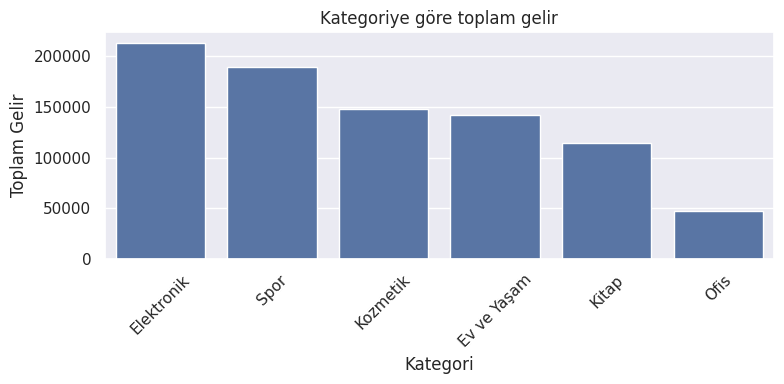

In [58]:
plt.figure(figsize=(8, 4))
sns.barplot(data=kategori_ozet.reset_index(), x="kategori", y="toplam_gelir")
plt.title("Kategoriye göre toplam gelir")
plt.xlabel("Kategori")
plt.ylabel("Toplam Gelir")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

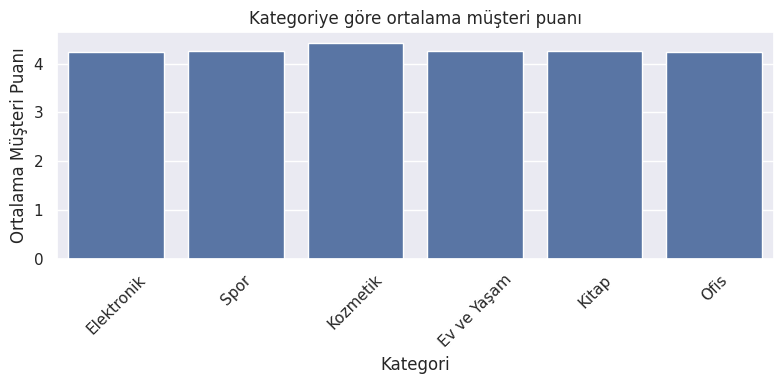

In [59]:
plt.figure(figsize=(8, 4))
sns.barplot(data=kategori_ozet.reset_index(), x="kategori", y="ortalama_musteri_puani")
plt.title("Kategoriye göre ortalama müşteri puanı")
plt.xlabel("Kategori")
plt.ylabel("Ortalama Müşteri Puanı")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### SORU 1 - İş Yorumu >> Elektronik, 212.930,29 TL toplam gelir ve 1.520,93 TL ile en yüksek sepet ortalamasına sahip olup şirketimizin ana ciro motorudur. Ancak sipariş sayısının (140) düşük olması, büyümenin işlem hacminden değil ürün pahalılığından kaynaklandığını gösteriyor. Hem yüksek sipariş hacmi (200) hem de 4.42 ile en yüksek müşteri memnuniyetini sağlayan Kozmetik ise genel müşteri memnuniyetini artırmak için en kritik kategoridir.

#### SORU 2 - Hangi şehirler daha yüksek potansiyel taşıyor?

In [60]:
sehir_ozet = (
    df_temiz.groupby("sehir")
    .agg(
        siparis_sayisi=("siparis_id", "count"),
        toplam_gelir=("toplam_tutar", "sum"),
        ortalama_siparis_tutari=("toplam_tutar", "mean"),
        ortalama_musteri_puani=("musteri_puani", "mean"),
    )
    .round(2)
    .sort_values("toplam_gelir", ascending=False)
)
sehir_ozet


,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani
sehir,,,,
İstanbul,264,224020.57,848.56,4.36
Ankara,124,96721.13,780.01,4.19
İzmir,118,88718.51,751.85,4.18
Antalya,86,63712.80,740.85,4.28
Konya,77,59424.33,771.74,4.36
Adana,63,50353.28,799.26,4.33
Bursa,67,46782.83,698.25,4.21
Mersin,46,38043.87,827.04,4.22
Eskişehir,45,37550.04,834.45,4.24


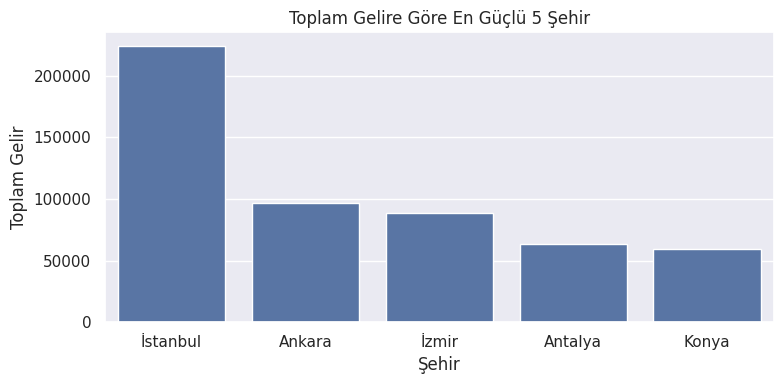

In [62]:
en_guclu_5_sehir = sehir_ozet.head(5).reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=en_guclu_5_sehir, x="sehir", y="toplam_gelir")
plt.title("Toplam Gelire Göre En Güçlü 5 Şehir")
plt.xlabel("Şehir")
plt.ylabel("Toplam Gelir")
plt.tight_layout()
plt.show()

In [63]:
medyan_gelir = sehir_ozet["toplam_gelir"].median()
buyume_adaylari = sehir_ozet[
    (sehir_ozet["ortalama_musteri_puani"] >= sehir_ozet["ortalama_musteri_puani"].median())
    & (sehir_ozet["toplam_gelir"] < medyan_gelir)
].sort_values("ortalama_musteri_puani", ascending=False)
buyume_adaylari

,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani
sehir,,,,
Samsun,45,36263.46,805.85,4.44
Gaziantep,49,35240.29,719.19,4.35
Kayseri,36,24878.81,691.08,4.28


#### SORU 2 - İş Yorumu >> Toplam gelir tarafında beklendiği gibi İstanbul, Ankara ve İzmir açık ara öne çıkmaktadır. Müşteri puanı yüksek (medyan üzeri) olmasına rağmen gelirde geride kalan Samsun (4.44), Gaziantep (4.35) ve Kayseri (4.28) ise en güçlü büyüme adayı şehirlerimizdir. Bu illerde müşteri memnuniyeti zaten yüksek olduğu için bölgesel reklam ve kargo kampanyalarıyla sipariş hacmi hızla artırılabilir.

#### SORU 3 - Hangi ödeme türü daha değerli müşteri davranışı üretiyor?

In [64]:
odeme_turu_ozet = (
    df_temiz.groupby("odeme_turu")
    .agg(
        siparis_sayisi=("siparis_id", "count"),
        toplam_gelir=("toplam_tutar", "sum"),
        ortalama_siparis_tutari=("toplam_tutar", "mean"),
        ortalama_musteri_puani=("musteri_puani", "mean"),
        ortalama_teslimat_gunu=("teslimat_gunu", "mean"),
    )
    .round(2)
    .sort_values("ortalama_siparis_tutari", ascending=False)
)
odeme_turu_ozet


,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani,ortalama_teslimat_gunu
odeme_turu,,,,,
Dijital Cüzdan,153,129911.25,849.09,4.27,3.27
Banka Kartı,169,143011.08,846.22,4.24,3.53
Havale/EFT,111,92894.46,836.89,4.15,3.14
Kredi Kartı,583,439468.16,753.80,4.31,3.31
Kapıda Ödeme,79,48113.17,609.03,4.38,3.24


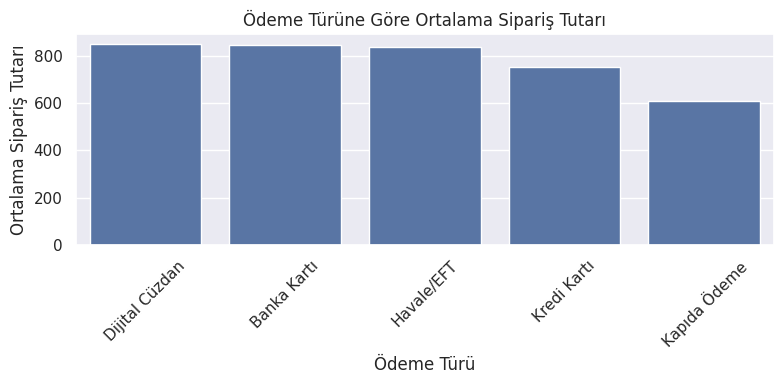

In [65]:
plt.figure(figsize=(8, 4))
sns.barplot(data=odeme_turu_ozet.reset_index(), x="odeme_turu", y="ortalama_siparis_tutari")
plt.title("Ödeme Türüne Göre Ortalama Sipariş Tutarı")
plt.xlabel("Ödeme Türü")
plt.ylabel("Ortalama Sipariş Tutarı")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

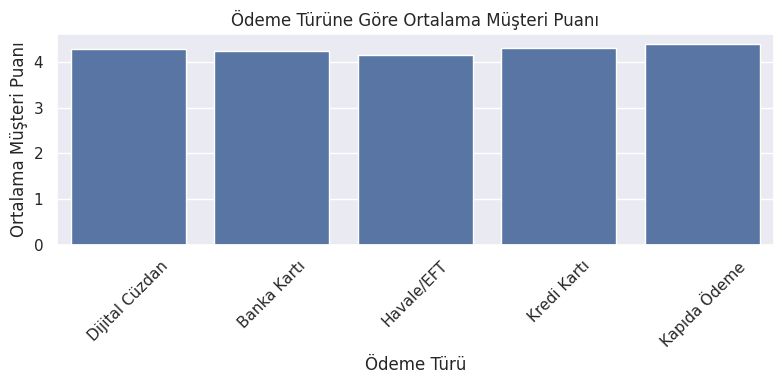

In [66]:
plt.figure(figsize=(8, 4))
sns.barplot(data=odeme_turu_ozet.reset_index(), x="odeme_turu", y="ortalama_musteri_puani")
plt.title("Ödeme Türüne Göre Ortalama Müşteri Puanı")
plt.xlabel("Ödeme Türü")
plt.ylabel("Ortalama Müşteri Puanı")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### SORU 3 - İş Yorumu >> En yüksek toplam geliri (439.468,16 TL) Kredi Kartı sağlarken, en yüksek sepet ortalamasını Dijital Cüzdan (849,09 TL) üretmektedir. Müşteri memnuniyetinde ise Kapıda Ödeme (4.38) öne çıksa da en düşük sepet ortalamasına (609,03 TL) sahiptir ve bu durum kapıda ödemenin güven algısı yaratıyor olabileceğini gösterir. Özetle, hem yüksek ciro hem de yüksek memnuniyet sunan Kredi Kartı en değerli müşteri davranışını oluşturmaktadır.

#### SORU 4 - Zaman içinde satış davranışı nasıl değişiyor?

In [67]:
aylik_ozet = (
    df_temiz.groupby("siparis_ayi")
    .agg(
        siparis_sayisi=("siparis_id", "count"),
        toplam_gelir=("toplam_tutar", "sum"),
        ortalama_siparis_tutari=("toplam_tutar", "mean"),
    )
    .round(2)
    .reset_index()
    .sort_values("siparis_ayi")
)
aylik_ozet

,siparis_ayi,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari
0,1,97,68309.45,704.22
1,2,84,67984.01,809.33
2,3,94,70857.89,753.81
3,4,111,68630.39,618.29
4,5,102,92213.41,904.05
5,6,85,77526.88,912.08
6,7,79,68774.62,870.56
7,8,80,55945.11,699.31
8,9,91,80591.62,885.62
9,10,89,60860.45,683.83


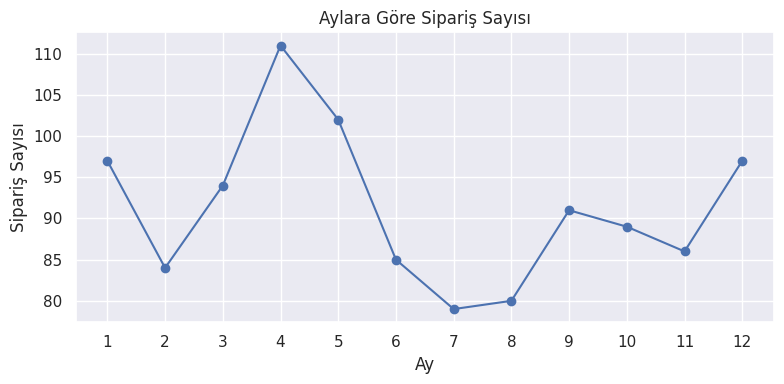

In [68]:
plt.figure(figsize=(8, 4))
plt.plot(aylik_ozet["siparis_ayi"], aylik_ozet["siparis_sayisi"], marker="o")
plt.title("Aylara Göre Sipariş Sayısı")
plt.xlabel("Ay")
plt.ylabel("Sipariş Sayısı")
plt.xticks(aylik_ozet["siparis_ayi"])
plt.tight_layout()
plt.show()

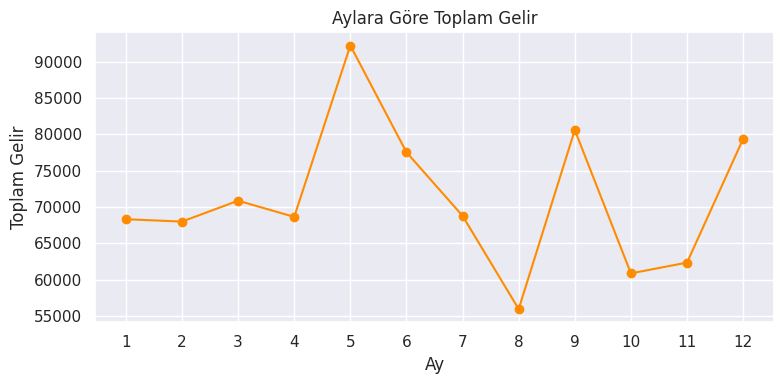

In [69]:
plt.figure(figsize=(8, 4))
plt.plot(aylik_ozet["siparis_ayi"], aylik_ozet["toplam_gelir"], marker="o", color="darkorange")
plt.title("Aylara Göre Toplam Gelir")
plt.xlabel("Ay")
plt.ylabel("Toplam Gelir")
plt.xticks(aylik_ozet["siparis_ayi"])
plt.tight_layout()
plt.show()

In [71]:
en_yogun_ay = aylik_ozet.loc[aylik_ozet["siparis_sayisi"].idxmax(), "siparis_ayi"]
en_gelirli_ay = aylik_ozet.loc[aylik_ozet["toplam_gelir"].idxmax(), "siparis_ayi"]
print("Sipariş sayısı bakımından en yoğun ay:", en_yogun_ay)
print("En yüksek gelirli ay:", en_gelirli_ay)

Sipariş sayısı bakımından en yoğun ay: 4
En yüksek gelirli ay: 5


#### SORU 4 - İş Yorumu >> En yoğun sipariş adedine Nisan ayında (111 sipariş) ulaşılırken, en yüksek toplam gelir Mayıs ayında (92.213,41 TL) elde edilmiştir. Bu durum, sipariş artışı ile gelir artışının aynı dönemde gerçekleşmediğini gösterir. Nisan'da indirimlerle ortalama sipariş tutarı düşerken, Mayıs'ta ortalama sipariş tutarının (904,05 TL) artması geliri zirveye taşımıştır.

#### SORU 5 - Hangi şehir-kategori kombinasyonları en güçlü fırsatı sunuyor?

In [72]:
sehir_kategori_ozet = (
    df_temiz.groupby(["sehir", "kategori"])
    .agg(
        siparis_sayisi=("siparis_id", "count"),
        toplam_gelir=("toplam_tutar", "sum"),
        ortalama_siparis_tutari=("toplam_tutar", "mean"),
        ortalama_musteri_puani=("musteri_puani", "mean"),
    )
    .round(2)
    .sort_values("toplam_gelir", ascending=False)
)
en_guclu_10_kombinasyon = sehir_kategori_ozet.head(10).reset_index()
en_guclu_10_kombinasyon

,sehir,kategori,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani
0,İstanbul,Elektronik,45,66731.92,1482.93,4.18
1,İstanbul,Spor,43,53391.34,1241.66,4.33
2,İstanbul,Ev ve Yaşam,43,34130.59,793.73,4.42
3,İstanbul,Kozmetik,42,33167.28,789.70,4.55
4,İstanbul,Kitap,56,27106.12,484.04,4.29
5,İzmir,Spor,26,25196.08,969.08,4.15
6,Ankara,Elektronik,15,23401.32,1560.09,4.13
7,Ankara,Spor,23,22817.79,992.08,4.35
8,Konya,Elektronik,15,22342.84,1489.52,4.40
9,İzmir,Elektronik,14,18487.02,1320.50,4.21


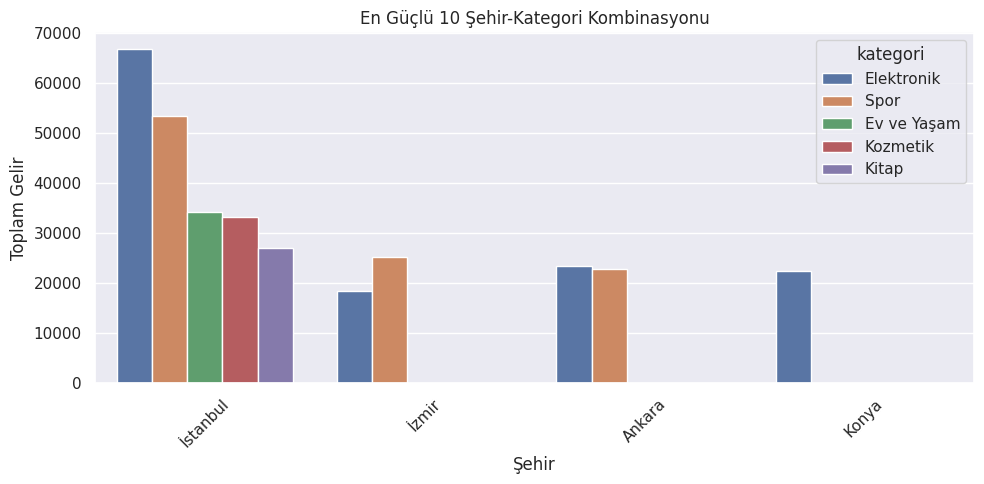

In [73]:
plt.figure(figsize=(10, 5))
sns.barplot(data=en_guclu_10_kombinasyon, x="sehir", y="toplam_gelir", hue="kategori")
plt.title("En Güçlü 10 Şehir-Kategori Kombinasyonu")
plt.xlabel("Şehir")
plt.ylabel("Toplam Gelir")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [74]:
en_guclu_kombinasyon = en_guclu_10_kombinasyon.iloc[0]
en_guclu_kombinasyon

,0
sehir,İstanbul
kategori,Elektronik
siparis_sayisi,45
toplam_gelir,66731.92
ortalama_siparis_tutari,1482.93
ortalama_musteri_puani,4.18


#### SORU 5 - İş Yorumu >> En yüksek geliri getiren ilk 3 kombinasyon sırasıyla İstanbul-Elektronik, İstanbul-Spor ve İstanbul-Ev ve Yaşam'dır. İlk 5 kombinasyonun tamamının İstanbul olması ciromuzun tek bir şehre bağımlı olduğunu ve risk taşıdığını gösterir. Pazarlama stratejisi olarak İstanbul'da yüksek tutarlı Elektronik ve Spor ürünleri öne çıkarılmalı, Ankara ve İzmir gibi ikincil pazarlarda da Elektronik kategorisi büyütülerek ciro riski dağıtılmalıdır.